In [6]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

data_dir = "/kaggle/input/skin-cancer-mnist-ham10000"

for root, dirs, files in os.walk(data_dir):
    print(f"\n Folder: {root}")
    for file in files[:10]:  
        print("  └──", file)


📁 Folder: /kaggle/input/skin-cancer-mnist-ham10000
  └── hmnist_8_8_RGB.csv
  └── hmnist_28_28_RGB.csv
  └── hmnist_8_8_L.csv
  └── hmnist_28_28_L.csv
  └── HAM10000_metadata.csv

📁 Folder: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1
  └── ISIC_0028933.jpg
  └── ISIC_0028394.jpg
  └── ISIC_0027799.jpg
  └── ISIC_0028100.jpg
  └── ISIC_0027960.jpg
  └── ISIC_0028872.jpg
  └── ISIC_0026412.jpg
  └── ISIC_0024872.jpg
  └── ISIC_0026232.jpg
  └── ISIC_0027031.jpg

📁 Folder: /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1
  └── ISIC_0028933.jpg
  └── ISIC_0028394.jpg
  └── ISIC_0027799.jpg
  └── ISIC_0028100.jpg
  └── ISIC_0027960.jpg
  └── ISIC_0028872.jpg
  └── ISIC_0026412.jpg
  └── ISIC_0024872.jpg
  └── ISIC_0026232.jpg
  └── ISIC_0027031.jpg

📁 Folder: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2
  └── ISIC_0030912.jpg
  └── ISIC_0030585.jpg
  └── ISIC_0033697.jpg
  └── ISIC_0030062.jpg
  └── ISIC_0031213.jpg
  └── ISIC_0031317.j

In [2]:
!pip install --upgrade transformers --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 96.7 MB/s eta 0:00:00:00:010:01


Metadata loaded: (10015, 7)


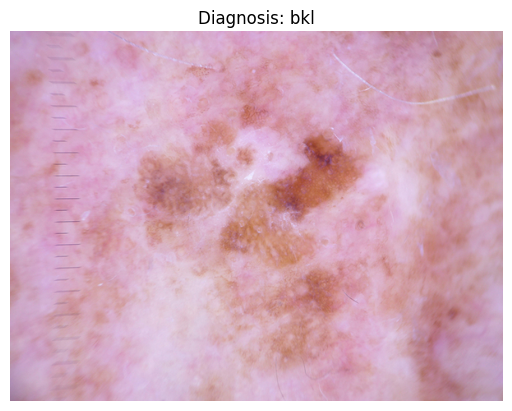

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
from sklearn.model_selection import train_test_split
from PIL import Image


base_dir = "/kaggle/input/skin-cancer-mnist-ham10000"
img_dir1 = os.path.join(base_dir, "HAM10000_images_part_1")
img_dir2 = os.path.join(base_dir, "HAM10000_images_part_2")
metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")

df = pd.read_csv(metadata_path)
print("Metadata loaded:", df.shape)
df.head()

def find_image_path(image_id):
    path1 = os.path.join(img_dir1, image_id + ".jpg")
    path2 = os.path.join(img_dir2, image_id + ".jpg")
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

sample_id = df['image_id'].iloc[0]
sample_path = find_image_path(sample_id)

if sample_path:
    image = Image.open(sample_path)
    plt.imshow(image)
    plt.title(f"Diagnosis: {df['dx'].iloc[0]}")
    plt.axis('off')
    plt.show()
else:
    print(f"Image {sample_id} not found in both directories.")


In [8]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [9]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [10]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [11]:
print("Missing 'age' before imputation:", df['age'].isna().sum())


df['age'] = df.groupby('dx')['age'].transform(lambda x: x.fillna(x.median()))


print("Missing 'age' after imputation:", df['age'].isna().sum())

Missing 'age' before imputation: 57
Missing 'age' after imputation: 0


In [12]:
benign_classes = ['nv', 'bkl', 'df', 'vasc']
malignant_classes = ['mel', 'bcc', 'akiec']


df['binary_class'] = df['dx'].apply(lambda x: 'benign' if x in benign_classes else 'malignant')

print(df['binary_class'].value_counts(normalize=True))


binary_class
benign       0.804893
malignant    0.195107
Name: proportion, dtype: float64


In [13]:
df.columns
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,binary_class
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,benign
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,benign
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,benign
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,benign
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,benign


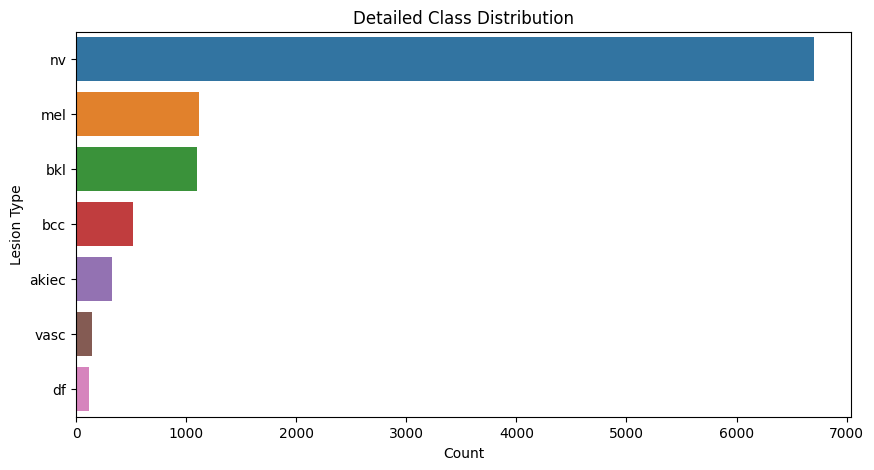

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(y='dx', data=df, order=df['dx'].value_counts().index)
plt.title('Detailed Class Distribution')
plt.xlabel('Count')
plt.ylabel('Lesion Type')
plt.show()

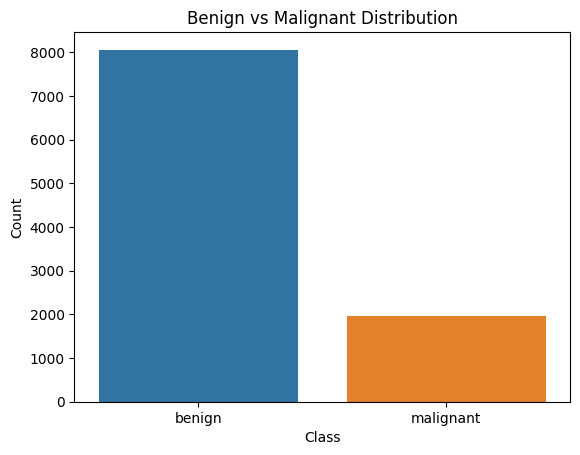

In [15]:
sns.countplot(x='binary_class', data=df)
plt.title('Benign vs Malignant Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


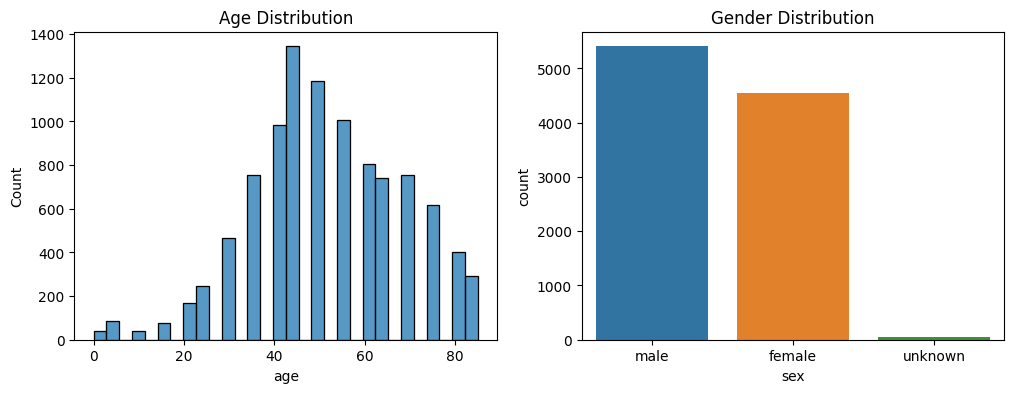

In [16]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

# Age Distribution
sns.histplot(df['age'].dropna(), bins=30, ax=ax[0])
ax[0].set_title('Age Distribution')

# Gender Distribution
sns.countplot(x='sex', data=df, ax=ax[1])
ax[1].set_title('Gender Distribution')

plt.show()


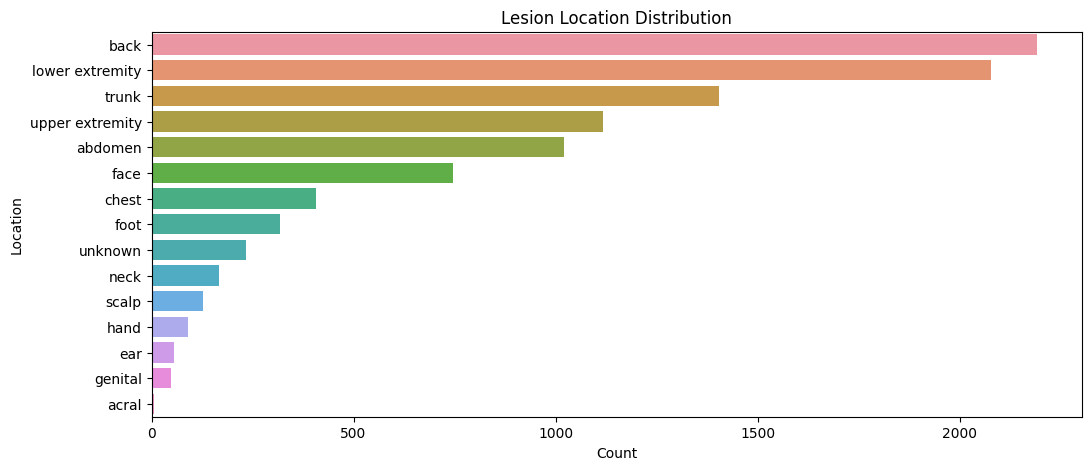

In [17]:
plt.figure(figsize=(12,5))
sns.countplot(y='localization', data=df, order=df['localization'].value_counts().index)
plt.title('Lesion Location Distribution')
plt.xlabel('Count')
plt.ylabel('Location')
plt.show()

In [18]:
source_dirs = [
    '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]

os.makedirs('all_images', exist_ok=True)

for source_dir in source_dirs:
    for file in os.listdir(source_dir):
        shutil.copy(os.path.join(source_dir, file), 'all_images')

print("Images copied successfully.")

Images copied successfully.


In [19]:
print(" Current Directory:", os.getcwd())
print("\n Folders in working directory:")
print(os.listdir('.'))

 Current Directory: /kaggle/working

 Folders in working directory:
['.virtual_documents', 'all_images']


In [20]:
folder_path = 'all_images'

os.listdir(folder_path)
len(os.listdir(folder_path))

10015

In [21]:
import os

print(os.listdir('all_images')[:5])
print(df['image_id'].head()) 

['ISIC_0026651.jpg', 'ISIC_0032934.jpg', 'ISIC_0029762.jpg', 'ISIC_0032250.jpg', 'ISIC_0029044.jpg']
0    ISIC_0027419
1    ISIC_0025030
2    ISIC_0026769
3    ISIC_0025661
4    ISIC_0031633
Name: image_id, dtype: object


In [22]:
df['image_id'] = df['image_id'].apply(lambda x: f"{x}.jpg")
print(os.listdir('all_images')[:5])
print(df['image_id'].head())

['ISIC_0026651.jpg', 'ISIC_0032934.jpg', 'ISIC_0029762.jpg', 'ISIC_0032250.jpg', 'ISIC_0029044.jpg']
0    ISIC_0027419.jpg
1    ISIC_0025030.jpg
2    ISIC_0026769.jpg
3    ISIC_0025661.jpg
4    ISIC_0031633.jpg
Name: image_id, dtype: object


In [23]:
data_gen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.10,
    brightness_range=[0.8, 1.2],
    rescale=1./255,
    validation_split=0.2
)

In [24]:

train_generator = data_gen.flow_from_dataframe(
    dataframe=df,
    directory='all_images',
    x_col='image_id',
    y_col='binary_class',
    target_size=(224, 224),
    class_mode='binary',
    batch_size=32,
    subset='training',
    seed=42
)


val_generator = data_gen.flow_from_dataframe(
    dataframe=df,
    directory='all_images',
    x_col='image_id',
    y_col='binary_class',
    target_size=(224, 224),
    class_mode='binary',
    batch_size=32,
    subset='validation',
    seed=42
)


Found 8012 validated image filenames belonging to 2 classes.
Found 2003 validated image filenames belonging to 2 classes.


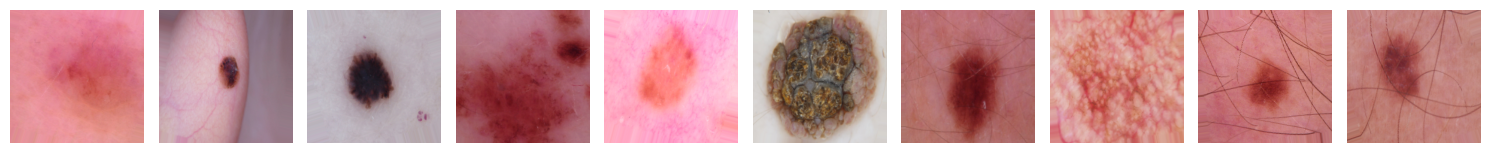

In [25]:
import matplotlib.pyplot as plt


images, labels = next(train_generator)

fig, axes = plt.subplots(1, 10, figsize=(15,15))
axes = axes.flatten()

for img, ax in zip(images, axes):
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()


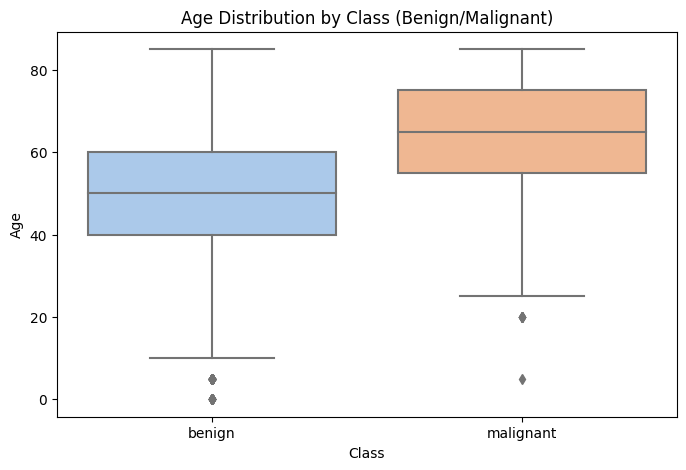

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='binary_class', y='age', data=df, palette='pastel')
plt.title('Age Distribution by Class (Benign/Malignant)')
plt.xlabel('Class')
plt.ylabel('Age')
plt.show()

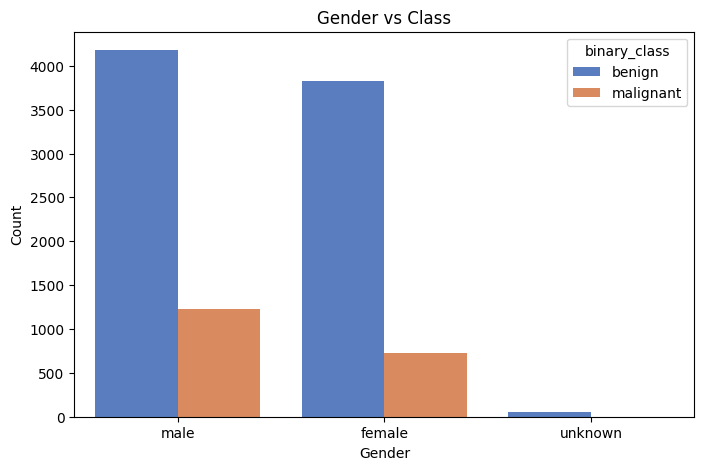

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='sex', hue='binary_class', data=df, palette='muted')
plt.title('Gender vs Class')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

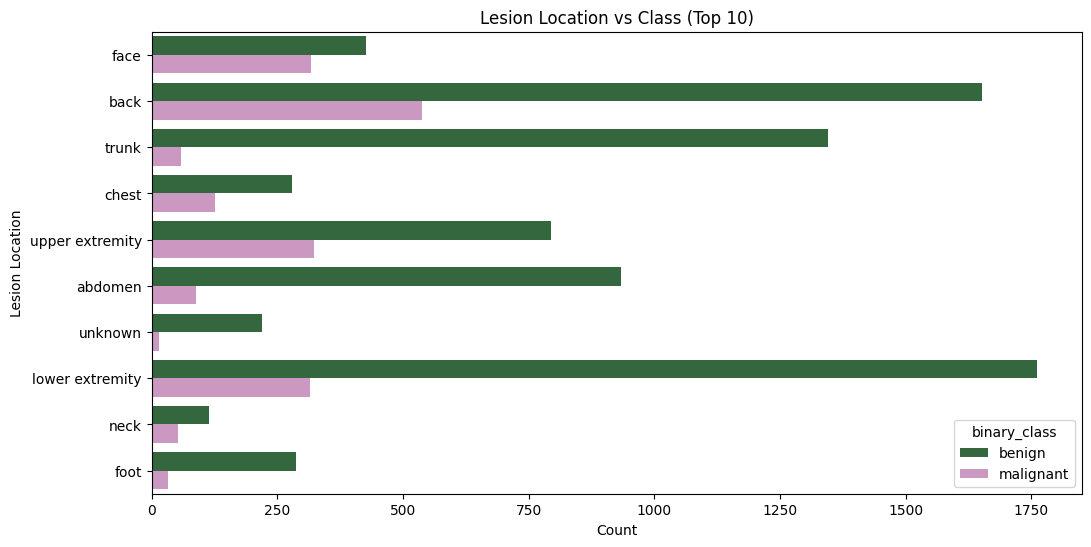

In [28]:
top_locs = df['localization'].value_counts().index[:10]

plt.figure(figsize=(12,6))
sns.countplot(y='localization', hue='binary_class', data=df[df['localization'].isin(top_locs)], palette='cubehelix')
plt.title('Lesion Location vs Class (Top 10)')
plt.xlabel('Count')
plt.ylabel('Lesion Location')
plt.show()

In [29]:
from scipy.stats import chi2_contingency

gender_table = pd.crosstab(df['sex'], df['binary_class'])
chi2, p, dof, ex = chi2_contingency(gender_table)
print(f'Gender vs Class: chi2={chi2:.2f}, p-value={p:.4f}')

loc_table = pd.crosstab(df['localization'], df['binary_class'])
chi2, p, dof, ex = chi2_contingency(loc_table)
print(f'Location vs Class: chi2={chi2:.2f}, p-value={p:.4f}')

gender_table = pd.crosstab(df['age'], df['binary_class'])
chi2, p, dof, ex = chi2_contingency(gender_table)
print(f'age vs Class: chi2={chi2:.2f}, p-value={p:.4f}')

gender_table = pd.crosstab(df['dx_type'], df['binary_class'])
chi2, p, dof, ex = chi2_contingency(gender_table)
print(f'dx_type vs Class: chi2={chi2:.2f}, p-value={p:.4f}')

Gender vs Class: chi2=85.08, p-value=0.0000
Location vs Class: chi2=806.79, p-value=0.0000
age vs Class: chi2=1299.87, p-value=0.0000
dx_type vs Class: chi2=2125.33, p-value=0.0000


In [30]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,                 
    stratify=df['binary_class'],   
    random_state=42                 
)

In [31]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,                  
    stratify=temp_df['binary_class'],
    random_state=42
)

In [32]:
print("Train class distribution:\n", train_df['binary_class'].value_counts(normalize=True))
print("\nValidation class distribution:\n", val_df['binary_class'].value_counts(normalize=True))
print("\nTest class distribution:\n", test_df['binary_class'].value_counts(normalize=True))

print(f"\nTotal samples — Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train class distribution:
 binary_class
benign       0.804918
malignant    0.195082
Name: proportion, dtype: float64

Validation class distribution:
 binary_class
benign       0.805195
malignant    0.194805
Name: proportion, dtype: float64

Test class distribution:
 binary_class
benign       0.804391
malignant    0.195609
Name: proportion, dtype: float64

Total samples — Train: 8012, Val: 1001, Test: 1002


In [33]:
os.makedirs('data/processed', exist_ok=True)
train_df.to_csv('data/processed/train_split.csv', index=False)
val_df.to_csv('data/processed/val_split.csv', index=False)
test_df.to_csv('data/processed/test_split.csv', index=False)

In [34]:
import torch
from torch import nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from transformers import ViTForImageClassification, ViTFeatureExtractor, Trainer, TrainingArguments,AutoImageProcessor
import pandas as pd

In [35]:
train_df = pd.read_csv("data/processed/train_split.csv")
val_df = pd.read_csv("data/processed/val_split.csv")
test_df = pd.read_csv("data/processed/test_split.csv")


In [36]:
label_map = {'benign': 0, 'malignant': 1}
train_df['label'] = train_df['binary_class'].map(label_map)
val_df['label'] = val_df['binary_class'].map(label_map)
test_df['label'] = test_df['binary_class'].map(label_map)

In [37]:
!ls -l /kaggle/input/saved-models/


total 0
drwxr-xr-x 8 nobody nogroup 0 Apr 25 18:11 saved_models


In [38]:
model_path = "/kaggle/input/saved-models/saved_models"


In [35]:
!ls -lh /kaggle/input/saved-models/saved_models/vit_final_model/


total 0
drwxr-xr-x 2 nobody nogroup 0 Apr 24 19:03 checkpoint-2400
drwxr-xr-x 2 nobody nogroup 0 Apr 24 19:03 checkpoint-2505


In [36]:
model_path = "/kaggle/input/saved-models/saved_models/vit-ham10000-best"
from transformers import ViTForImageClassification
model = ViTForImageClassification.from_pretrained(model_path)


In [38]:
# feature_extractor = AutoImageProcessor.from_pretrained(
#     "/kaggle/input/vit-base-patch16-224-in21k"
# )
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
# ])


In [39]:
from transformers import ViTForImageClassification, ViTFeatureExtractor,ViTImageProcessor

model_path = "/kaggle/input/vit-b16" 

model = ViTForImageClassification.from_pretrained(model_path, num_labels=2)
feature_extractor = ViTImageProcessor.from_pretrained(model_path)


Some weights of ViTForImageClassification were not initialized from the model checkpoint at /kaggle/input/vit-b16 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [40]:
print(model.config)
print(feature_extractor.image_mean)

ViTConfig {
  "_attn_implementation_autoset": true,
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.51.1"
}

[0.5, 0.5, 0.5]


In [41]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
])

In [42]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return {'pixel_values': image, 'labels': torch.tensor(row['label'], dtype=torch.long)}

In [43]:
train_dataset = HAM10000Dataset(train_df, 'all_images', transform)
val_dataset = HAM10000Dataset(val_df, 'all_images', transform)
test_dataset = HAM10000Dataset(test_df, 'all_images', transform)

In [44]:
import transformers
print(transformers.__version__)

4.51.1


In [40]:
from transformers import TrainingArguments
print(TrainingArguments.__module__)

transformers.training_args


In [41]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit_ham10000",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    logging_dir="./logs",
    logging_steps=10,
    save_steps=200,
    save_total_limit=2,
    do_eval=True,
    report_to="none"
)
def compute_metrics(pred):
    preds = pred.predictions.argmax(-1)
    labels = pred.label_ids
    acc = (preds == labels).mean()
    return {"accuracy": acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
10,0.516100
20,0.380100
30,0.371300
40,0.398500
50,0.334700
60,0.335100
70,0.314200
80,0.319200
90,0.314600
100,0.336700


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

TrainOutput(global_step=1255, training_loss=0.1314268278707546, metrics={'train_runtime': 1178.1871, 'train_samples_per_second': 34.001, 'train_steps_per_second': 1.065, 'total_flos': 3.1043291039605555e+18, 'train_loss': 0.1314268278707546, 'epoch': 5.0})

In [42]:
trainer.evaluate(test_dataset)


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'eval_loss': 0.38765138387680054,
 'eval_accuracy': 0.9041916167664671,
 'eval_runtime': 15.1907,
 'eval_samples_per_second': 65.961,
 'eval_steps_per_second': 2.107,
 'epoch': 5.0}

In [43]:
trainer.save_model("vit-ham10000-trial1")


In [44]:
def compute_metrics(pred):
    preds = pred.predictions.argmax(-1)
    labels = pred.label_ids

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }


In [45]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit_ham10000",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=7,           # You can go up to 15
    learning_rate=3e-5,            # Custom learning rate
    logging_dir="./logs",
    logging_steps=10,
    save_steps=200,
    save_total_limit=2,
    do_eval=True,
    report_to="none"
)


In [46]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [47]:
trainer.train()


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
10,0.031800
20,0.024200
30,0.022000
40,0.037000
50,0.044300
60,0.070500
70,0.018400
80,0.020400
90,0.045700
100,0.011800


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

TrainOutput(global_step=1757, training_loss=0.01039437023211455, metrics={'train_runtime': 1651.4853, 'train_samples_per_second': 33.96, 'train_steps_per_second': 1.064, 'total_flos': 4.3460607455447777e+18, 'train_loss': 0.01039437023211455, 'epoch': 7.0})

In [48]:
print("Validation Metrics:")
val_results = trainer.evaluate(val_dataset)
print(val_results)

print("Test Metrics:")
test_results = trainer.evaluate(test_dataset)
print(test_results)

Validation Metrics:


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'eval_loss': 0.4934682548046112, 'eval_accuracy': 0.9200799200799201, 'eval_precision': 0.852760736196319, 'eval_recall': 0.7128205128205128, 'eval_f1': 0.776536312849162, 'eval_runtime': 15.8993, 'eval_samples_per_second': 62.959, 'eval_steps_per_second': 2.013, 'epoch': 7.0}
Test Metrics:


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'eval_loss': 0.6560618877410889, 'eval_accuracy': 0.8932135728542914, 'eval_precision': 0.7633136094674556, 'eval_recall': 0.6581632653061225, 'eval_f1': 0.706849315068493, 'eval_runtime': 15.3431, 'eval_samples_per_second': 65.306, 'eval_steps_per_second': 2.086, 'epoch': 7.0}


In [49]:
trainer.save_model("vit-ham10000-trial2")


In [50]:
!pip install optuna


In [51]:
import optuna

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.3)
    }


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.argmax(axis=1)

    try:
        acc = accuracy_score(labels, preds)
        prec = precision_score(labels, preds, zero_division=0)
        rec = recall_score(labels, preds, zero_division=0)
        f1 = f1_score(labels, preds, zero_division=0)
    except Exception as e:
        print("⚠️ Metrics error:", e)
        acc = prec = rec = f1 = 0.0

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }


In [53]:
from transformers import TrainingArguments, Trainer

def training_loop(trial):
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
    wd = trial.suggest_float("weight_decay", 0.0, 0.3)

    training_args = TrainingArguments(
        output_dir="./vit_optuna_trial",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=10,  # quick for tuning
        learning_rate=lr,
        weight_decay=wd,
        logging_dir="./logs",
        logging_steps=10,
        save_steps=500,
        save_total_limit=1,
        do_eval=True,
        report_to="none"
    )

    
    import copy
    model_copy = copy.deepcopy(model)

    trainer = Trainer(
        model=model_copy,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_result = trainer.evaluate()
    f1 = eval_result.get("f1", 0.0)
    print("Trial result (F1):", f1)
    return f1

In [54]:
study = optuna.create_study(direction="maximize")
study.optimize(training_loop, n_trials=5) 

print("Best hyperparameters:", study.best_params)
print("Best F1 score:", study.best_value)


[I 2025-04-22 15:36:18,821] A new study created in memory with name: no-name-8c8fe150-77cc-4f23-b183-3f78b8b4ab3f
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
10,0.273800
20,0.320500
30,0.422000
40,0.263200
50,0.290900
60,0.314000
70,0.228600
80,0.247400
90,0.155200
100,0.203400


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

[I 2025-04-22 16:15:47,539] Trial 0 finished with value: 0.0 and parameters: {'learning_rate': 0.00017258614414073208, 'weight_decay': 0.1477802564451531}. Best is trial 0 with value: 0.0.


Trial result (F1): 0.0


...

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
10,0.595500
20,0.398400
30,0.359300
40,0.375400
50,0.293500
60,0.389800
70,0.413500
80,0.360500
90,0.327700
100,0.359600


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

[I 2025-04-22 18:53:28,051] Trial 4 finished with value: 0.0 and parameters: {'learning_rate': 0.0002977746411588467, 'weight_decay': 0.06399573062695468}. Best is trial 0 with value: 0.0.


Trial result (F1): 0.0
Best hyperparameters: {'learning_rate': 0.00017258614414073208, 'weight_decay': 0.1477802564451531}
Best F1 score: 0.0


In [55]:
predictions_output = trainer.predict(val_dataset)
pred_labels = predictions_output.predictions.argmax(axis=1)
true_labels = predictions_output.label_ids


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [56]:
import numpy as np
import pandas as pd

# Check unique prediction values and their counts
pred_counts = pd.Series(pred_labels).value_counts()
true_counts = pd.Series(true_labels).value_counts()

print("Predicted labels distribution:\n", pred_counts)
print("Actual labels distribution:\n", true_counts)


Predicted labels distribution:
 0    838
1    163
Name: count, dtype: int64
Actual labels distribution:
 0    806
1    195
Name: count, dtype: int64


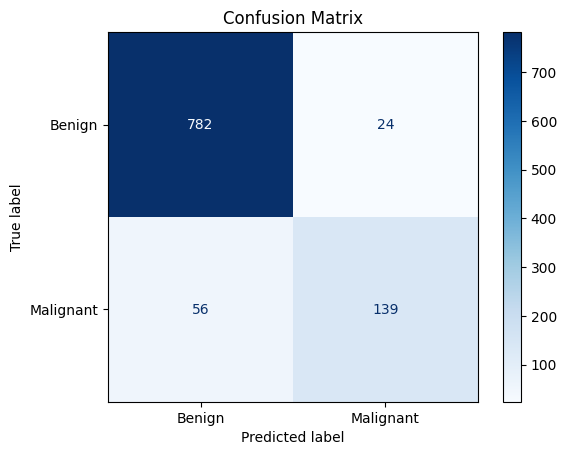

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [58]:
best_params = study.best_params
print(best_params)


{'learning_rate': 0.00017258614414073208, 'weight_decay': 0.1477802564451531}


In [59]:
from transformers import TrainingArguments, Trainer

final_training_args = TrainingArguments(
    output_dir="./vit_final_model",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5, 
    learning_rate=best_params["learning_rate"],
    weight_decay=best_params["weight_decay"],
    logging_steps=10,
    logging_dir="./logs",
    save_steps=200,
    save_total_limit=2,
    do_eval=True,
    report_to="none"
)

final_trainer = Trainer(
    model=model,  
    args=final_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

final_trainer.train()


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
10,0.271400
20,0.280200
30,0.309800
40,0.277100
50,0.185800
60,0.275300
70,0.251400
80,0.222000
90,0.170000
100,0.147100


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

TrainOutput(global_step=1255, training_loss=0.07796237689639586, metrics={'train_runtime': 1182.443, 'train_samples_per_second': 33.879, 'train_steps_per_second': 1.061, 'total_flos': 3.1043291039605555e+18, 'train_loss': 0.07796237689639586, 'epoch': 5.0})

In [60]:
test_results = final_trainer.evaluate(test_dataset)
print("Final Test Results:", test_results)


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Final Test Results: {'eval_loss': 0.5482290983200073, 'eval_accuracy': 0.9021956087824351, 'eval_precision': 0.7987804878048781, 'eval_recall': 0.6683673469387755, 'eval_f1': 0.7277777777777779, 'eval_runtime': 15.2432, 'eval_samples_per_second': 65.734, 'eval_steps_per_second': 2.099, 'epoch': 5.0}


In [61]:
final_trainer.save_model("vit-ham10000-best")


In [62]:
import os


os.listdir()

['vit_optuna_trial',
 '.virtual_documents',
 'vit_ham10000',
 'data',
 'vit-ham10000-trial2',
 'vit-ham10000-best',
 'vit_final_model',
 'all_images',
 'vit-ham10000-trial1']

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


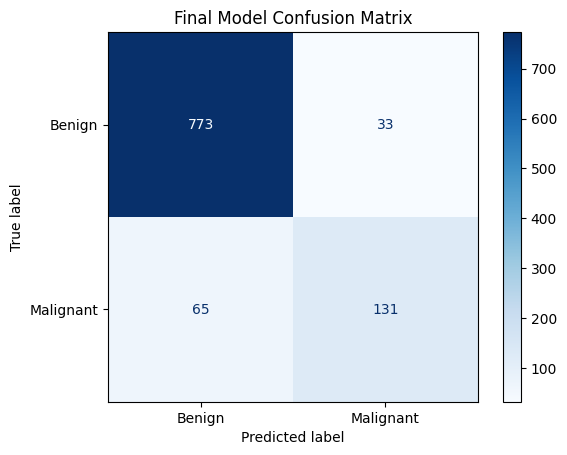

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions_output = final_trainer.predict(test_dataset)
pred_labels = predictions_output.predictions.argmax(axis=1)
true_labels = predictions_output.label_ids

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title("Final Model Confusion Matrix")
plt.show()


📊 Final Test Results
Accuracy: 0.9022
Precision: 0.7988
Recall: 0.6684
F1 Score: 0.7278

📝 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       806
           1       0.80      0.67      0.73       196

    accuracy                           0.90      1002
   macro avg       0.86      0.81      0.83      1002
weighted avg       0.90      0.90      0.90      1002



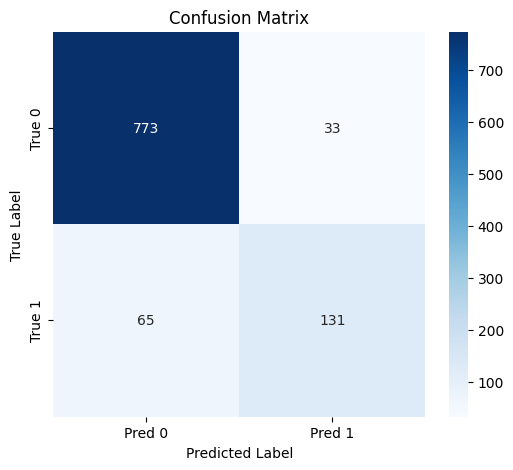

In [64]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns


accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, average='binary')
recall = recall_score(true_labels, pred_labels, average='binary')
f1 = f1_score(true_labels, pred_labels, average='binary')


print("📊 Final Test Results")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")



print("\n📝 Classification Report:")
print(classification_report(true_labels, pred_labels))


conf_matrix = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()




In [50]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

metadata = df[['age', 'sex', 'localization']]

metadata_encoder = ColumnTransformer(
    transformers=[
        ('age', StandardScaler(), ['age']),
        ('gender', OneHotEncoder(), ['sex']),
        ('site', OneHotEncoder(), ['localization'])
    ]
)

metadata_encoded = metadata_encoder.fit_transform(metadata)

print("Encoded metadata shape:", metadata_encoded.shape)


Encoded metadata shape: (10015, 19)


In [51]:
metadata_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30045 stored elements and shape (10015, 19)>

In [44]:
from torch.utils.data import Dataset
import torch
from PIL import Image

class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, image_transform, metadata_encoder):
        self.dataframe = dataframe
        self.transform = image_transform
        self.metadata_encoder = metadata_encoder

        self.metadata = metadata_encoder.transform(
            dataframe[['age', 'sex', 'localization']]
        )
        
    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_id"]).convert('RGB')
        if self.transform:
            image = self.transform(image)

        metadata = torch.tensor(self.metadata[idx], dtype=torch.float)

        label = torch.tensor(row["binary_class"], dtype=torch.long)

        return {
            'pixel_values': image,
            'metadata': metadata,
            'labels': label
        }


In [45]:
import torch.nn as nn
from transformers import ViTModel

class ViTWithMetadata(nn.Module):
    def __init__(self, metadata_dim, num_classes=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        vit_output_dim = self.vit.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(vit_output_dim + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, pixel_values, metadata):
        vit_features = self.vit(pixel_values=pixel_values).pooler_output
        combined_features = torch.cat([vit_features, metadata], dim=1)
        logits = self.classifier(combined_features)
        return logits


In [46]:
from transformers import Trainer

class TrainerWithMetadata(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        pixel_values = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")

        logits = model(pixel_values, metadata)
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        
        return (loss, logits) if return_outputs else loss


In [47]:
from transformers import Trainer

class TrainerWithMetadata(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        pixel_values = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")

        logits = model(pixel_values, metadata)
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        
        return (loss, logits) if return_outputs else loss


In [56]:
!pip install --upgrade transformers


In [48]:
from transformers import TrainingArguments
from torchvision import transforms
# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_dataset = SkinLesionDataset(train_df, transform, metadata_encoder)
val_dataset = SkinLesionDataset(val_df, transform, metadata_encoder)

metadata_dim = train_dataset.metadata.shape[1]
model = ViTWithMetadata(metadata_dim=metadata_dim)

args = TrainingArguments(
    output_dir='./vit-metadata-model',
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    learning_rate=2e-5,
    logging_steps=50,
    save_total_limit=2,
    save_steps=200
)


trainer = TrainerWithMetadata(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()


NameError: name 'metadata_encoder' is not defined

In [49]:
# 1. Imports
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torchvision import transforms
from transformers import ViTModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

BASE_VIT_PATH = "/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/"
IMG_DIR = "all_images"

meta_encoder = ColumnTransformer([
    ("age", StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site", OneHotEncoder(sparse=False), ["localization"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[['age', 'sex', 'localization']])

class SkinLesionWithMeta(Dataset):
    def __init__(self, df, img_dir, transform, meta_encoder):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        m = meta_encoder.transform(self.df[['age', 'sex', 'localization']])
        self.meta = m.toarray() if hasattr(m, "toarray") else m
        self.labels = self.df['binary_class'].map({'benign': 0, 'malignant': 1}).astype(int).values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        name = row.image_id
        if not name.lower().endswith(('.jpg', '.jpeg', '.png')):
            name += '.jpg'
        path = os.path.join(self.img_dir, name)
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        meta = torch.tensor(self.meta[i], dtype=torch.float)
        label = torch.tensor(self.labels[i], dtype=torch.long)
        return {"pixel_values": img, "metadata": meta, "labels": label, "label": label}


class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained(BASE_VIT_PATH, local_files_only=True, ignore_mismatched_sizes=True)
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, pixel_values, metadata):
        out = self.vit(pixel_values=pixel_values).pooler_output
        combined = torch.cat((out, metadata), dim=1)
        return self.classifier(combined)

class TrainerWithMeta(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        labels = inputs.pop("labels")
        pixels = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")
        logits = model(pixels, metadata)
        loss = nn.CrossEntropyLoss()(logits, labels)
        return (loss, logits) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labs = p.label_ids
    return {
        "accuracy": accuracy_score(labs, preds),
        "precision": precision_score(labs, preds, zero_division=0),
        "recall": recall_score(labs, preds, zero_division=0),
        "f1": f1_score(labs, preds, zero_division=0),
    }

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = SkinLesionWithMeta(train_df, IMG_DIR, transform, meta_encoder)
val_ds = SkinLesionWithMeta(val_df, IMG_DIR, transform, meta_encoder)
test_ds = SkinLesionWithMeta(test_df, IMG_DIR, transform, meta_encoder)

metadata_dim = train_ds.meta.shape[1]
model = ViTWithMeta(metadata_dim=metadata_dim)

args = TrainingArguments(
    output_dir="./vit-metadata",
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    learning_rate=3e-5,
    logging_steps=50,
    save_steps=200,
    save_total_limit=2,
    report_to="none"
)

trainer = TrainerWithMeta(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

val_results = trainer.evaluate()
test_results = trainer.evaluate(test_ds)

import ace_tools as tools
tools.display_dataframe_to_user(
    name="Validation and Test Results",
    dataframe=pd.DataFrame([val_results, test_results], index=["Validation", "Test"])
)


test_dataset = SkinLesionDataset(test_df, transform, metadata_encoder)
predictions = trainer.predict(test_dataset)

# Accuracy
pred_labels = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids

from sklearn.metrics import classification_report
print(classification_report(true_labels, pred_labels, target_names=["Benign", "Malignant"]))


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,0.274100
100,0.052100
150,0.014500
200,0.014400
250,0.021100
300,0.010900
350,0.009500
400,0.008400
450,0.018600
500,0.002500


TypeError: ViTWithMeta.forward() got an unexpected keyword argument 'labels'

In [ ]:
# os.makedirs('resized_images', exist_ok=True)

# image_path = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
# image_path2 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2'


In [ ]:
# def resize_images(image_dir):
#     for image_name in os.listdir(image_dir):
#         img = Image.open(os.path.join(image_dir, image_name))
#         img = img.resize((224, 224))
#         img.save(f'resized_images/{image_name}')

# print("📂 Current Directory:", os.getcwd())
# print("\n📁 Folders in working directory:")
# print(os.listdir('.'))

In [50]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")

meta_encoder = ColumnTransformer([
    ("age",    StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site",   OneHotEncoder(sparse=False), ["localization"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age", "sex", "localization"]])


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


ColumnTransformer(transformers=[('age', StandardScaler(), ['age']),
                                ('gender', OneHotEncoder(sparse=False),
                                 ['sex']),
                                ('site', OneHotEncoder(sparse=False),
                                 ['localization'])])

In [51]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class SkinLesionWithMeta(Dataset):
    def __init__(self, df, img_dir, transform, meta_encoder):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        m = meta_encoder.transform(self.df[['age', 'sex', 'localization']])
        self.meta = m.toarray() if hasattr(m, "toarray") else m
        self.labels = self.df['binary_class'].map({'benign': 0, 'malignant': 1}).astype(int).values

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_path = os.path.join("all_images", row.image_id + ".jpg")
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        meta = torch.tensor(self.meta[i], dtype=torch.float)
        label = torch.tensor(self.labels[i], dtype=torch.long)
        return {"pixel_values": img, "metadata": meta, "labels": label}


In [52]:
from transformers import ViTModel
import torch.nn as nn

class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained("/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/", local_files_only=True)
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )
    def forward(self, pixel_values, metadata, **kwargs):
        out = self.vit(pixel_values=pixel_values).pooler_output
        combined = torch.cat((out, metadata), dim=1)
        logits = self.classifier(combined)
        return {"logits": logits}
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        labels = inputs.pop("labels")
        pixels = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")
        
        outputs = model(pixels, metadata)       # returns {"logits": ...}
        logits = outputs["logits"]              # extract logits

        loss = nn.CrossEntropyLoss()(logits, labels)
        return (loss, outputs) if return_outputs else loss
    


In [53]:
metadata_sample = meta_encoder.transform(test_df[["age", "sex", "localization"]])
metadata_dim = metadata_sample.shape[1]


In [54]:
from transformers import ViTModel

metadata_dim = train_ds.meta.shape[1]
model = ViTWithMeta(metadata_dim=metadata_dim)

model.vit = ViTModel.from_pretrained(
    "/kaggle/working/vit-metadata/checkpoint-501",
    local_files_only=True
)

model.eval()


Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTWithMeta(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn): 

In [55]:
trainer = TrainerWithMeta(
    model=model,
    args=args,  # reuse old training args
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

val_results = trainer.evaluate()
test_results = trainer.evaluate(test_ds)


In [56]:
print(test_results)


{'eval_model_preparation_time': 0.0027, 'eval_runtime': 14.0383, 'eval_samples_per_second': 71.376, 'eval_steps_per_second': 4.488}


In [57]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torchvision import transforms
from transformers import ViTModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")

\meta_encoder = ColumnTransformer([
    ("age", StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site", OneHotEncoder(sparse=False), ["localization"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age", "sex", "localization"]])

class SkinLesionWithMeta(Dataset):
    def __init__(self, df, img_dir, transform, meta_encoder):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        m = meta_encoder.transform(self.df[['age', 'sex', 'localization']])
        self.meta = m.toarray() if hasattr(m, "toarray") else m
        self.labels = self.df['binary_class'].map({'benign': 0, 'malignant': 1}).astype(int).values

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_path = os.path.join("all_images", row.image_id)
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        meta = torch.tensor(self.meta[i], dtype=torch.float)
        label = torch.tensor(self.labels[i], dtype=torch.long)
        return {"pixel_values": img, "metadata": meta, "labels": label}

class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained(
            "/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/",
            local_files_only=True
        )
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, pixel_values, metadata, **kwargs):
        out = self.vit(pixel_values=pixel_values).pooler_output
        combined = torch.cat((out, metadata), dim=1)
        logits = self.classifier(combined)
        return {"logits": logits}

class TrainerWithMeta(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        metadata = inputs.pop("metadata")
        pixel_values = inputs.pop("pixel_values")

        outputs = model(pixel_values=pixel_values, metadata=metadata)
        logits = outputs["logits"] if isinstance(outputs, dict) else outputs

        loss = nn.CrossEntropyLoss()(logits, labels)

        if return_outputs:
            return loss, logits  # <- return logits, not dict
        else:
            return loss


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = SkinLesionWithMeta(train_df, "all_images", transform, meta_encoder)
val_ds   = SkinLesionWithMeta(val_df,   "all_images", transform, meta_encoder)
test_ds  = SkinLesionWithMeta(test_df,  "all_images", transform, meta_encoder)

metadata_dim = train_ds.meta.shape[1]
model = ViTWithMeta(metadata_dim=metadata_dim)

args = TrainingArguments(
    output_dir="./vit-metadata",
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=16,
    logging_steps=50,
    report_to="none"
)

trainer = TrainerWithMeta(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

val_results = trainer.evaluate()
test_results = trainer.evaluate(test_ds)

print("Validation Accuracy:", val_results.get("eval_accuracy"))
print("Test Accuracy:", test_results.get("eval_accuracy"))


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Validation Accuracy: None
Test Accuracy: None


In [58]:
# Imports
import os, torch, pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from transformers import ViTModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers.modeling_outputs import SequenceClassifierOutput

train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")

meta_encoder = ColumnTransformer([
    ("age",    StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site",   OneHotEncoder(sparse=False), ["localization"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age", "sex", "localization"]])

class SkinLesionWithMeta(Dataset):
    def __init__(self, df, img_dir, transform, meta_encoder):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.meta = meta_encoder.transform(self.df[['age', 'sex', 'localization']])
        self.meta = self.meta.toarray() if hasattr(self.meta, "toarray") else self.meta
        self.labels = self.df['binary_class'].map({'benign': 0, 'malignant': 1}).astype(int).values

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_path = os.path.join("all_images", row.image_id)
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        meta = torch.tensor(self.meta[i], dtype=torch.float)
        label = torch.tensor(self.labels[i], dtype=torch.long)
        return {"pixel_values": img, "metadata": meta, "labels": label}

class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained(
            "/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/", 
            local_files_only=True
        )
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, pixel_values, metadata, labels=None):
        vit_out = self.vit(pixel_values=pixel_values).pooler_output
        combined = torch.cat((vit_out, metadata), dim=1)
        logits = self.classifier(combined)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return SequenceClassifierOutput(loss=loss, logits=logits)

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labels = p.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0)
    }

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = SkinLesionWithMeta(train_df, "all_images", transform, meta_encoder)
val_ds   = SkinLesionWithMeta(val_df, "all_images", transform, meta_encoder)
test_ds  = SkinLesionWithMeta(test_df, "all_images", transform, meta_encoder)

metadata_dim = train_ds.meta.shape[1]
model = ViTWithMeta(metadata_dim=metadata_dim)
print("1tina")

args = TrainingArguments(
    output_dir="./vit-metadata",
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,  # can increase
    learning_rate=3e-5,
    logging_steps=50,
    save_steps=200,
    save_total_limit=2,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()
print("tina")
val_results = trainer.evaluate()
test_results = trainer.evaluate(test_ds)

print("Validation Accuracy:", val_results.get("eval_accuracy"))
print("Test Accuracy:", test_results.get("eval_accuracy"))


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


1tina


Step,Training Loss
50,0.279400
100,0.046000
150,0.020400
200,0.021700
250,0.007100
300,0.009800
350,0.007500
400,0.002800
450,0.002400
500,0.008400


tina


Validation Accuracy: 0.9100899100899101
Test Accuracy: 0.9121756487025948


In [59]:
trainer.save_model("./vit-metadata-final")


In [60]:
import os
print(os.listdir("./vit-metadata-final"))


['training_args.bin', 'model.safetensors']


In [61]:
import torch
from safetensors.torch import load_file
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

model = ViTWithMeta(metadata_dim=metadata_dim)
state_dict = load_file("./vit-metadata-final/model.safetensors")
model.load_state_dict(state_dict)
model.eval()

trainer = TrainerWithMeta(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

val_preds = trainer.predict(val_ds)
test_preds = trainer.predict(test_ds)


min_len_val = min(len(val_pred_labels), len(val_true_labels))
min_len_test = min(len(test_pred_labels), len(test_true_labels))

# Trim both to min length
val_pred_labels = val_pred_labels[:min_len_val]
val_true_labels = val_true_labels[:min_len_val]
test_pred_labels = test_pred_labels[:min_len_test]
test_true_labels = test_true_labels[:min_len_test]

# Metrics
print("\n📊 Validation Classification Report:")
print(classification_report(val_true_labels, val_pred_labels, target_names=["Benign", "Malignant"]))

print("\n🧪 Test Classification Report:")
print(classification_report(test_true_labels, test_pred_labels, target_names=["Benign", "Malignant"]))




Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


NameError: name 'val_pred_labels' is not defined

In [62]:

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torchvision import transforms
from transformers import ViTModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")


label_mapping = {'benign': 0, 'malignant': 1}
train_df['binary_class'] = train_df['binary_class'].map(label_mapping)
val_df['binary_class'] = val_df['binary_class'].map(label_mapping)
test_df['binary_class'] = test_df['binary_class'].map(label_mapping)


meta_encoder = ColumnTransformer([
    ("age", StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site", OneHotEncoder(sparse=False), ["localization"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age", "sex", "localization"]])


class SkinLesionWithMeta(Dataset):
    def __init__(self, dataframe,image_dir, transform, metadata_encoder):
        self.dataframe = dataframe
        self.transform = transform
        self.image_dir = image_dir 
        self.metadata_encoder = metadata_encoder

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # Load and transform the image
        img_path = os.path.join(self.image_dir, row['image_id'])  # <--- Fix
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)

        # Prepare metadata (correct way)
        meta_input = pd.DataFrame([{
            "age": row["age"],
            "sex": row["sex"],
            "localization": row["localization"]
        }])
        metadata = self.metadata_encoder.transform(meta_input).squeeze()

        # Target label
        label = row['binary_class']

        return {
            "pixel_values": image,
            "metadata": torch.tensor(metadata, dtype=torch.float),
            "labels": torch.tensor(label, dtype=torch.long)
        }


class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained("/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/", local_files_only=True)
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, pixel_values, metadata, **kwargs):
        out = self.vit(pixel_values=pixel_values).pooler_output
        logits = self.classifier(torch.cat((out, metadata), dim=1))
        return {"logits": logits}

class TrainerWithMeta(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels", None)
        pixel_values = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")
        if labels is None:
            raise ValueError("No 'labels' found in inputs. Please check your Dataset output.")
        outputs = model(pixel_values, metadata)
        logits = outputs["logits"]
        weights = torch.tensor([1.0, 3.0]).to(logits.device)  # Assuming class imbalance
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labels = p.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = SkinLesionWithMeta(train_df,"/kaggle/working/all_images",transform, meta_encoder)
val_ds   = SkinLesionWithMeta(val_df,"/kaggle/working/all_images", transform, meta_encoder)
test_ds  = SkinLesionWithMeta(test_df,"/kaggle/working/all_images",transform, meta_encoder)

meta_fields = train_df[['age', 'sex', 'localization']]
sample_meta = meta_fields.iloc[[0]]  # <--- use double brackets here
transformed_sample = meta_encoder.transform(sample_meta)
metadata_dim = transformed_sample.shape[1]

model = ViTWithMeta(metadata_dim=metadata_dim)

args = TrainingArguments(
    output_dir="./vit-meta-final",
    do_train=True,
    do_eval=True,
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    logging_steps=50,
    save_steps=300,
    save_total_limit=2,
    metric_for_best_model="f1",
    greater_is_better=True,
    remove_unused_columns=False,
    label_names=["labels"],    
    report_to="none"
)

trainer = TrainerWithMeta(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

val_preds = trainer.predict(val_ds)
test_preds = trainer.predict(test_ds)

val_true = val_preds.label_ids
val_pred = val_preds.predictions.argmax(-1)
test_true = test_preds.label_ids
test_pred = test_preds.predictions.argmax(-1)

print("Validation Accuracy:", accuracy_score(val_true, val_pred))
print("Test Accuracy:", accuracy_score(test_true, test_pred))
print("\n Validation Classification Report:\n", classification_report(val_true, val_pred, target_names=["Benign", "Malignant"]))
print("\n Test Classification Report:\n", classification_report(test_true, test_pred, target_names=["Benign", "Malignant"]))


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,0.356200
100,0.238200
150,0.246800
200,0.215900
250,0.167500
300,0.137200
350,0.149700
400,0.145000
450,0.140700
500,0.177100


Validation Accuracy: 0.916083916083916
Test Accuracy: 0.9051896207584831

📊 Validation Classification Report:
               precision    recall  f1-score   support

      Benign       0.94      0.96      0.95       806
   Malignant       0.82      0.73      0.77       195

    accuracy                           0.92      1001
   macro avg       0.88      0.85      0.86      1001
weighted avg       0.91      0.92      0.91      1001


📊 Test Classification Report:
               precision    recall  f1-score   support

      Benign       0.94      0.95      0.94       806
   Malignant       0.77      0.73      0.75       196

    accuracy                           0.91      1002
   macro avg       0.85      0.84      0.85      1002
weighted avg       0.90      0.91      0.90      1002



In [63]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torchvision import transforms
from transformers import ViTModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")

label_mapping = {'benign': 0, 'malignant': 1}
train_df['binary_class'] = train_df['binary_class'].map(label_mapping)
val_df['binary_class'] = val_df['binary_class'].map(label_mapping)
test_df['binary_class'] = test_df['binary_class'].map(label_mapping)

meta_encoder = ColumnTransformer([
    ("age", StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site", OneHotEncoder(sparse=False), ["localization"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age", "sex", "localization"]])

class SkinLesionWithMeta(Dataset):
    def __init__(self, dataframe,image_dir, transform, metadata_encoder):
        self.dataframe = dataframe
        self.transform = transform
        self.image_dir = image_dir 
        self.metadata_encoder = metadata_encoder

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_path = os.path.join(self.image_dir, row['image_id'])  # <--- Fix
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)

        meta_input = pd.DataFrame([{
            "age": row["age"],
            "sex": row["sex"],
            "localization": row["localization"]
        }])
        metadata = self.metadata_encoder.transform(meta_input).squeeze()

        label = row['binary_class']

        return {
            "pixel_values": image,
            "metadata": torch.tensor(metadata, dtype=torch.float),
            "labels": torch.tensor(label, dtype=torch.long)
        }

class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained("/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/", local_files_only=True)
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, pixel_values, metadata, **kwargs):
        out = self.vit(pixel_values=pixel_values).pooler_output
        logits = self.classifier(torch.cat((out, metadata), dim=1))
        return {"logits": logits}

class TrainerWithMeta(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.epoch_metrics = [] 

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels", None)
        pixel_values = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")
        if labels is None:
            raise ValueError("No 'labels' found in inputs.")
        outputs = model(pixel_values, metadata)
        logits = outputs["logits"]
        weights = torch.tensor([1.0, 3.0]).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix: str = "eval"):
        output = super().evaluate(eval_dataset, ignore_keys, metric_key_prefix)
        # Save metrics for plotting later
        self.epoch_metrics.append({
            "epoch": int(self.state.epoch),
            "accuracy": output.get("eval_accuracy", 0),
            "precision": output.get("eval_precision", 0),
            "recall": output.get("eval_recall", 0),
            "f1": output.get("eval_f1", 0)
        })
        return output


def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labels = p.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = SkinLesionWithMeta(train_df,"/kaggle/working/all_images",transform, meta_encoder)
val_ds   = SkinLesionWithMeta(val_df,"/kaggle/working/all_images", transform, meta_encoder)
test_ds  = SkinLesionWithMeta(test_df,"/kaggle/working/all_images",transform, meta_encoder)

meta_fields = train_df[['age', 'sex', 'localization']]
sample_meta = meta_fields.iloc[[0]]  # <--- use double brackets here
transformed_sample = meta_encoder.transform(sample_meta)
metadata_dim = transformed_sample.shape[1]

model = ViTWithMeta(metadata_dim=metadata_dim)

args = TrainingArguments(
    output_dir="./vit-meta-final",
    do_train=True,
    do_eval=True,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    logging_steps=50,
    save_steps=300,
    save_total_limit=2,
    metric_for_best_model="f1",
    greater_is_better=True,
    remove_unused_columns=False,
    label_names=["labels"],    
    report_to="none"
)

trainer = TrainerWithMeta(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

val_preds = trainer.predict(val_ds)
test_preds = trainer.predict(test_ds)

val_true = val_preds.label_ids
val_pred = val_preds.predictions.argmax(-1)
test_true = test_preds.label_ids
test_pred = test_preds.predictions.argmax(-1)

print("Validation Accuracy:", accuracy_score(val_true, val_pred))
print("Test Accuracy:", accuracy_score(test_true, test_pred))
print("\n Validation Classification Report:\n", classification_report(val_true, val_pred, target_names=["Benign", "Malignant"]))
print("\n Test Classification Report:\n", classification_report(test_true, test_pred, target_names=["Benign", "Malignant"]))


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,0.342000
100,0.223600
150,0.200300
200,0.202700
250,0.163600
300,0.179400
350,0.167600
400,0.190800
450,0.155000
500,0.139900


Validation Accuracy: 0.9280719280719281
Test Accuracy: 0.9121756487025948

📊 Validation Classification Report:
               precision    recall  f1-score   support

      Benign       0.95      0.97      0.96       806
   Malignant       0.84      0.77      0.81       195

    accuracy                           0.93      1001
   macro avg       0.90      0.87      0.88      1001
weighted avg       0.93      0.93      0.93      1001


📊 Test Classification Report:
               precision    recall  f1-score   support

      Benign       0.93      0.96      0.95       806
   Malignant       0.83      0.70      0.76       196

    accuracy                           0.91      1002
   macro avg       0.88      0.83      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [65]:
!pip install -U transformers


In [70]:

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torchvision import transforms
from transformers import ViTModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")


label_mapping = {'benign': 0, 'malignant': 1}
for df in [train_df, val_df, test_df]:
    df['binary_class'] = df['binary_class'].map(label_mapping)


meta_encoder = ColumnTransformer([
    ("age", StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site", OneHotEncoder(sparse=False), ["localization"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age", "sex", "localization"]])


class SkinLesionWithMeta(Dataset):
    def __init__(self, dataframe, image_dir, transform, metadata_encoder):
        self.dataframe = dataframe
        self.transform = transform
        self.image_dir = image_dir 
        self.metadata_encoder = metadata_encoder

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_id'])
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        meta_input = pd.DataFrame([{
            "age": row["age"],
            "sex": row["sex"],
            "localization": row["localization"]
        }])
        metadata = self.metadata_encoder.transform(meta_input).squeeze()
        label = row['binary_class']
        return {
            "pixel_values": image,
            "metadata": torch.tensor(metadata, dtype=torch.float),
            "labels": torch.tensor(label, dtype=torch.long)
        }


class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained("/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/", local_files_only=True)
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, pixel_values, metadata, **kwargs):
        out = self.vit(pixel_values=pixel_values).pooler_output
        logits = self.classifier(torch.cat((out, metadata), dim=1))
        return {"logits": logits}


class TrainerWithMeta(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels", None)
        pixel_values = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")
        outputs = model(pixel_values, metadata)
        logits = outputs["logits"]
        weights = torch.tensor([1.0, 3.0]).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labels = p.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


image_dir = "/kaggle/working/all_images"
train_ds = SkinLesionWithMeta(train_df, image_dir, transform, meta_encoder)
val_ds   = SkinLesionWithMeta(val_df, image_dir, transform, meta_encoder)
test_ds  = SkinLesionWithMeta(test_df, image_dir, transform, meta_encoder)

meta_fields = train_df[['age', 'sex', 'localization']]
sample_meta = meta_fields.iloc[[0]]
transformed_sample = meta_encoder.transform(sample_meta)
metadata_dim = transformed_sample.shape[1]

model = ViTWithMeta(metadata_dim=metadata_dim)

args = TrainingArguments(
    output_dir="./vit-meta-final",
    do_train=True,
    do_eval=True,
    num_train_epochs=1,  # we manually control 5 epochs
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    logging_steps=50,
    save_steps=300,
    save_total_limit=2,
    remove_unused_columns=False,
    label_names=["labels"],
    report_to="none"
)

trainer = TrainerWithMeta(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)


epoch_results = []

for epoch in range(5):
    print(f"\n⏳ Starting Epoch {epoch + 1}...\n")
    trainer.train()
    
    val_preds = trainer.predict(val_ds)
    val_true = val_preds.label_ids
    val_pred = val_preds.predictions.argmax(-1)

    val_acc = accuracy_score(val_true, val_pred)
    val_prec = precision_score(val_true, val_pred, zero_division=0)
    val_rec = recall_score(val_true, val_pred, zero_division=0)
    val_f1 = f1_score(val_true, val_pred, zero_division=0)

    print(f"✅ Epoch {epoch+1}: Accuracy={val_acc:.4f}, Precision={val_prec:.4f}, Recall={val_rec:.4f}, F1={val_f1:.4f}")

    epoch_results.append({
        "epoch": epoch + 1,
        "accuracy": val_acc,
        "precision": val_prec,
        "recall": val_rec,
        "f1": val_f1
    })


best_epoch = max(epoch_results, key=lambda x: x["f1"])
print(f"\n Best Epoch: {best_epoch['epoch']}")
print(f" Accuracy:  {best_epoch['accuracy']:.4f}")
print(f" Precision: {best_epoch['precision']:.4f}")
print(f" Recall:    {best_epoch['recall']:.4f}")
print(f" F1 Score:  {best_epoch['f1']:.4f}")

test_preds = trainer.predict(test_ds)
test_true = test_preds.label_ids
test_pred = test_preds.predictions.argmax(-1)

print("\n Final Test Set Performance:")
print("Test Accuracy:", accuracy_score(test_true, test_pred))
print("\n Test Classification Report:\n", classification_report(test_true, test_pred, target_names=["Benign", "Malignant"]))


`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



⏳ Starting Epoch 1...



Step,Training Loss
50,0.382600
100,0.224300
150,0.160500
200,0.141400
250,0.144500


✅ Epoch 1: Accuracy=0.9021, Precision=0.7513, Recall=0.7436, F1=0.7474

⏳ Starting Epoch 2...



Step,Training Loss
50,0.109100
100,0.124200
150,0.127300
200,0.084100
250,0.107900


...

Step,Training Loss
50,0.060000
100,0.061700
150,0.095900
200,0.066700
250,0.081800


✅ Epoch 4: Accuracy=0.9091, Precision=0.7796, Recall=0.7436, F1=0.7612

⏳ Starting Epoch 5...



Step,Training Loss
50,0.031500
100,0.048200
150,0.056800
200,0.055900
250,0.086900


✅ Epoch 5: Accuracy=0.9161, Precision=0.8000, Recall=0.7590, F1=0.7789

🏆 Best Epoch: 5
✔️ Accuracy:  0.9161
✔️ Precision: 0.8000
✔️ Recall:    0.7590
✔️ F1 Score:  0.7789



📊 Final Test Set Performance:
Test Accuracy: 0.9141716566866267

📊 Test Classification Report:
               precision    recall  f1-score   support

      Benign       0.94      0.96      0.95       806
   Malignant       0.81      0.73      0.77       196

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.86      1002
weighted avg       0.91      0.91      0.91      1002



In [66]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torchvision import transforms
from transformers import ViTModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")

label_mapping = {'benign': 0, 'malignant': 1}
for df in [train_df, val_df, test_df]:
    df['binary_class'] = df['binary_class'].map(label_mapping)

meta_encoder = ColumnTransformer([
    ("age", StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site", OneHotEncoder(sparse=False), ["localization"]),
    ("dx_type",OneHotEncoder(sparse=False),["dx_type"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age", "sex", "localization","dx_type"]])

class SkinLesionWithMeta(Dataset):
    def __init__(self, dataframe, image_dir, transform, metadata_encoder):
        self.dataframe = dataframe
        self.transform = transform
        self.image_dir = image_dir 
        self.metadata_encoder = metadata_encoder

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_id'])
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        meta_input = pd.DataFrame([{
            "age": row["age"],
            "sex": row["sex"],
            "localization": row["localization"],
            "dx_type":row["dx_type"]
        }])
        metadata = self.metadata_encoder.transform(meta_input).squeeze()
        label = row['binary_class']
        return {
            "pixel_values": image,
            "metadata": torch.tensor(metadata, dtype=torch.float),
            "labels": torch.tensor(label, dtype=torch.long)
        }

class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained("/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/", local_files_only=True)
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, pixel_values, metadata, **kwargs):
        out = self.vit(pixel_values=pixel_values).pooler_output
        logits = self.classifier(torch.cat((out, metadata), dim=1))
        return {"logits": logits}

class TrainerWithMeta(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels", None)
        pixel_values = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")
        outputs = model(pixel_values, metadata)
        logits = outputs["logits"]
        weights = torch.tensor([1.0, 3.0]).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labels = p.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

image_dir = "/kaggle/working/all_images"
train_ds = SkinLesionWithMeta(train_df, image_dir, transform, meta_encoder)
val_ds   = SkinLesionWithMeta(val_df, image_dir, transform, meta_encoder)
test_ds  = SkinLesionWithMeta(test_df, image_dir, transform, meta_encoder)

meta_fields = train_df[['age', 'sex', 'localization','dx_type']]
sample_meta = meta_fields.iloc[[0]]
transformed_sample = meta_encoder.transform(sample_meta)
metadata_dim = transformed_sample.shape[1]

model = ViTWithMeta(metadata_dim=metadata_dim)

args = TrainingArguments(
    output_dir="./vit-meta-final",
    do_train=True,
    do_eval=True,
    num_train_epochs=1,  # we manually control 5 epochs
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    logging_steps=50,
    save_steps=300,
    save_total_limit=2,
    remove_unused_columns=False,
    label_names=["labels"],
    report_to="none"
)

trainer = TrainerWithMeta(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

epoch_results = []

for epoch in range(5):
    print(f"\n⏳ Starting Epoch {epoch + 1}...\n")
    trainer.train()
    
    val_preds = trainer.predict(val_ds)
    val_true = val_preds.label_ids
    val_pred = val_preds.predictions.argmax(-1)

    val_acc = accuracy_score(val_true, val_pred)
    val_prec = precision_score(val_true, val_pred, zero_division=0)
    val_rec = recall_score(val_true, val_pred, zero_division=0)
    val_f1 = f1_score(val_true, val_pred, zero_division=0)

    print(f" Epoch {epoch+1}: Accuracy={val_acc:.4f}, Precision={val_prec:.4f}, Recall={val_rec:.4f}, F1={val_f1:.4f}")

    epoch_results.append({
        "epoch": epoch + 1,
        "accuracy": val_acc,
        "precision": val_prec,
        "recall": val_rec,
        "f1": val_f1
    })

best_epoch = max(epoch_results, key=lambda x: x["f1"])
print(f"\n Best Epoch: {best_epoch['epoch']}")
print(f" Accuracy:  {best_epoch['accuracy']:.4f}")
print(f" Precision: {best_epoch['precision']:.4f}")
print(f" Recall:    {best_epoch['recall']:.4f}")
print(f" F1 Score:  {best_epoch['f1']:.4f}")

test_preds = trainer.predict(test_ds)
test_true = test_preds.label_ids
test_pred = test_preds.predictions.argmax(-1)

print("\n Final Test Set Performance:")
print("Test Accuracy:", accuracy_score(test_true, test_pred))
print("\n Test Classification Report:\n", classification_report(test_true, test_pred, target_names=["Benign", "Malignant"]))

torch.save(model.state_dict(), "./vit-meta-final/vit_with_meta_final.pth")

torch.save(model, "./vit-meta-final/vit_with_meta_full_model.pth")


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.


⏳ Starting Epoch 1...



Step,Training Loss
50,0.384600
100,0.256800
150,0.234400
200,0.181800
250,0.165600
300,0.137000
350,0.150400
400,0.157700
450,0.147100
500,0.140900


✅ Epoch 1: Accuracy=0.9171, Precision=0.8111, Recall=0.7487, F1=0.7787

⏳ Starting Epoch 2...



Step,Training Loss
50,0.098000
100,0.140800
150,0.135000
200,0.143100
250,0.118900
300,0.129200
350,0.082500
400,0.061700
450,0.092500
500,0.161300


...

Step,Training Loss
50,0.010700
100,0.068800
150,0.066500
200,0.098600
250,0.068900
300,0.082100
350,0.090200
400,0.049600
450,0.087200
500,0.103600


✅ Epoch 4: Accuracy=0.9131, Precision=0.7967, Recall=0.7436, F1=0.7692

⏳ Starting Epoch 5...



Step,Training Loss
50,0.023700
100,0.063800
150,0.054600
200,0.052200
250,0.043600
300,0.103500
350,0.061700
400,0.056400
450,0.092400
500,0.101800


✅ Epoch 5: Accuracy=0.9241, Precision=0.8182, Recall=0.7846, F1=0.8010

🏆 Best Epoch: 5
✔️ Accuracy:  0.9241
✔️ Precision: 0.8182
✔️ Recall:    0.7846
✔️ F1 Score:  0.8010



📊 Final Test Set Performance:
Test Accuracy: 0.9131736526946108

📊 Test Classification Report:
               precision    recall  f1-score   support

      Benign       0.94      0.96      0.95       806
   Malignant       0.80      0.74      0.77       196

    accuracy                           0.91      1002
   macro avg       0.87      0.85      0.86      1002
weighted avg       0.91      0.91      0.91      1002



/tmp/ipykernel_31/969822154.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


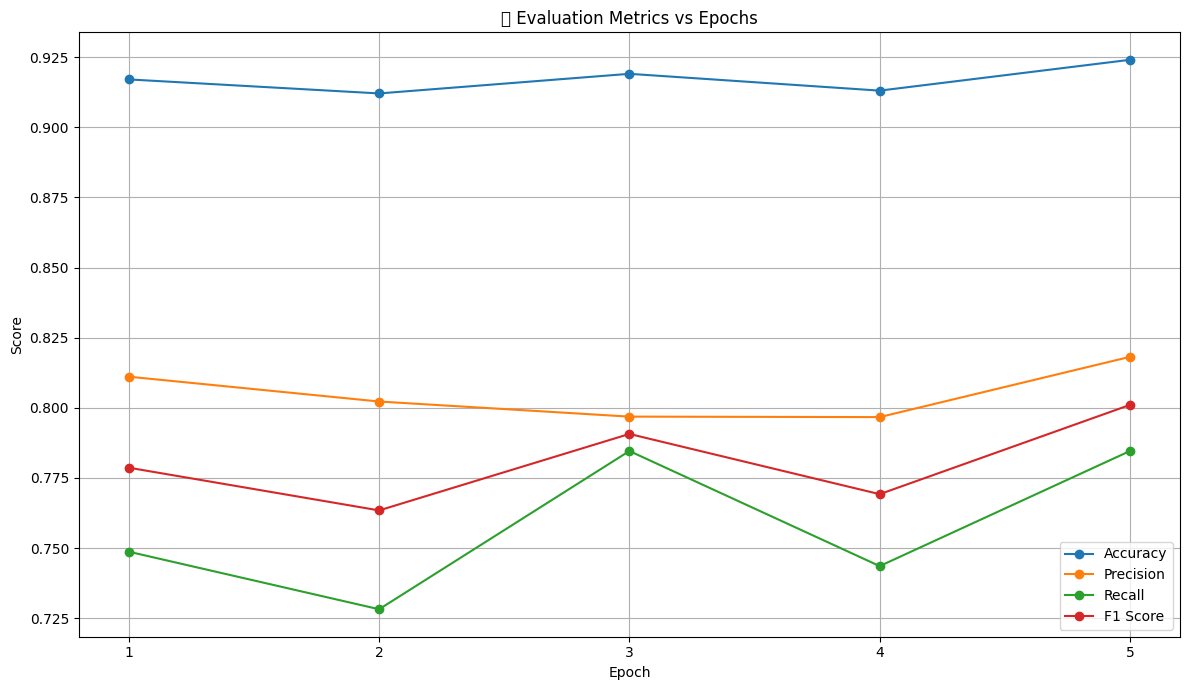

In [67]:
import matplotlib.pyplot as plt

epochs = [result['epoch'] for result in epoch_results]
accuracies = [result['accuracy'] for result in epoch_results]
precisions = [result['precision'] for result in epoch_results]
recalls = [result['recall'] for result in epoch_results]
f1_scores = [result['f1'] for result in epoch_results]

plt.figure(figsize=(12, 7))

plt.plot(epochs, accuracies, marker='o', label='Accuracy')
plt.plot(epochs, precisions, marker='o', label='Precision')
plt.plot(epochs, recalls, marker='o', label='Recall')
plt.plot(epochs, f1_scores, marker='o', label='F1 Score')

plt.title('📊 Evaluation Metrics vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.xticks(epochs) 
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [77]:
!pip install timm torchcam --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.0 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is inco

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


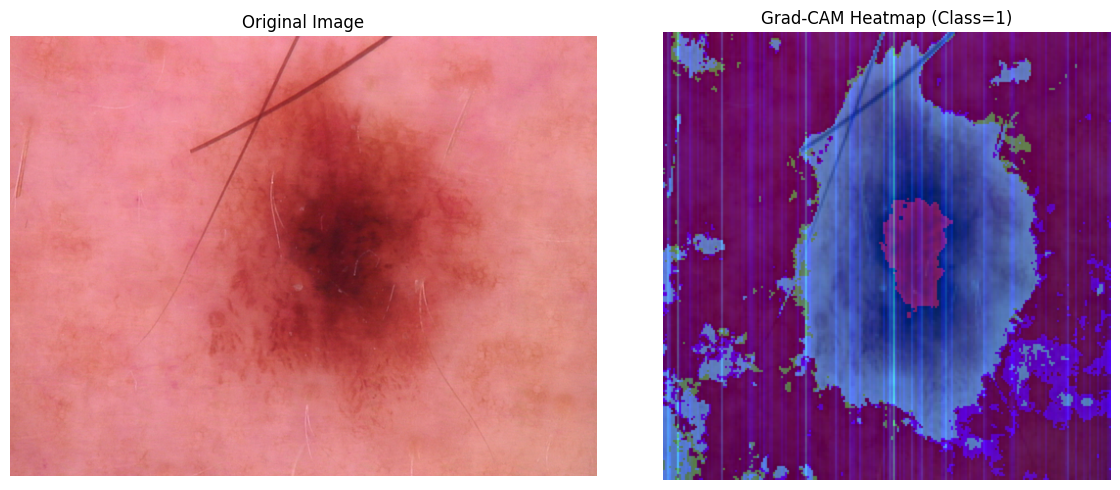

In [117]:
import os
import torch
import torch.nn as nn
from transformers import ViTModel
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

# 1. Wrapper for ViT
class ViTWrapper(nn.Module):
    def __init__(self, hf_model):
        super().__init__()
        self.vit = hf_model

    def forward(self, x):
        return self.vit(pixel_values=x).pooler_output  # output tensor

sample_meta = pd.DataFrame([{
    "age": 55,
    "sex": "male",
    "localization": "trunk"
}])
meta_encoder = ColumnTransformer([
    ("age", StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site", OneHotEncoder(sparse=False), ["localization"])
])
meta_encoder.fit(sample_meta)
metadata_dim = meta_encoder.transform(sample_meta).shape[1]

hf_vit = ViTModel.from_pretrained("/kaggle/working/vit-meta-final/checkpoint-251", local_files_only=True)
wrapped_vit = ViTWrapper(hf_vit)
wrapped_vit.eval()

target_layer = wrapped_vit.vit.encoder.layer[-1].output
cam_extractor = SmoothGradCAMpp(wrapped_vit, target_layer=target_layer)

img_path = "/kaggle/working/all_images/ISIC_0024306.jpg"
image = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
input_tensor = transform(image).unsqueeze(0)

output = wrapped_vit(input_tensor)

target_class = 1
cam = cam_extractor(class_idx=[target_class])[0].cpu()

heatmap = overlay_mask(to_pil_image(transform(image)), to_pil_image(cam, mode='F'), alpha=0.5)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(heatmap)
ax[1].set_title(f'Grad-CAM Heatmap (Class={target_class})')
ax[1].axis('off')
plt.tight_layout()
plt.show()

In [38]:
!pip install torchcam --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is inc

In [39]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

from transformers import ViTModel
from your_module import ViTWithMeta 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

metadata_dim = meta_encoder.transform(
    pd.DataFrame([{"age":55,"sex":"male","localization":"trunk"}])
).shape[1]

model = ViTWithMeta(metadata_dim=metadata_dim)
model.load_state_dict(torch.load("./vit-meta-final/pytorch_model.bin", map_location="cpu"))
model.eval()

class ViTFeatureExtractor(nn.Module):
    def __init__(self, vit: ViTModel):
        super().__init__()
        self.vit = vit
    def forward(self, pixel_values):
        return self.vit(pixel_values=pixel_values).pooler_output

wrapped_vit = ViTFeatureExtractor(model.vit)

target_layer = wrapped_vit.vit.encoder.layer[-1].output
cam_extractor = SmoothGradCAMpp(wrapped_vit, target_layer=target_layer)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


def classify_and_cam(img_path, meta_dict):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0)  # B×3×224×224

    
    meta_df = pd.DataFrame([meta_dict])
    m = meta_encoder.transform(meta_df)
    m = torch.tensor(m, dtype=torch.float)

   
    with torch.no_grad():
        outputs = model(pixel_values=x, metadata=m)
        logits = outputs["logits"]
        probs = torch.softmax(logits, dim=-1)[0]
        pred = torch.argmax(probs).item()

    
    _ = wrapped_vit(x)                     
    cam = cam_extractor(class_idx=[pred])[0].cpu()

    
    heatmap = overlay_mask(
        to_pil_image(transform(img)),
        to_pil_image(cam, mode="F"),
        alpha=0.5
    )
    return {
        "image": img,
        "heatmap": heatmap,
        "pred_class": pred,
        "pred_confidence": float(probs[pred])
    }


meta_example = {"age": 55, "sex": "male", "localization": "trunk"}
res = classify_and_cam("/kaggle/working/all_images/ISIC_0024306.jpg", meta_example)

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(res["image"]);     ax[0].set_title("Original");    ax[0].axis("off")
ax[1].imshow(res["heatmap"]);   ax[1].set_title(f"CAM → class {res['pred_class']}"); ax[1].axis("off")
ax[2].bar(["benign","malig."], [1-res["pred_confidence"], res["pred_confidence"]])
ax[2].set_title("Confidence");  ax[2].set_ylim(0,1)
plt.show()


examples = [
    ("/kaggle/working/all_images/ISIC_0024306.jpg", {"age":55,"sex":"male","localization":"trunk"}),
    ("/kaggle/working/all_images/ISIC_0031234.jpg", {"age":45,"sex":"female","localization":"face"}),
]
for path, meta in examples:
    out = classify_and_cam(path, meta)
    print(f"{os.path.basename(path)} → predicted {out['pred_class']} @ {out['pred_confidence']:.2f}")
    plt.figure(figsize=(6,6))
    plt.imshow(out["heatmap"])
    plt.title(f"{os.path.basename(path)}\nClass {out['pred_class']} ({out['pred_confidence']:.2f})")
    plt.axis("off")
    plt.show()


ModuleNotFoundError: No module named 'your_module'

In [ ]:
gradcam_batch(wrapped_vit, test_ds, n_correct=5, n_incorrect=5)


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.

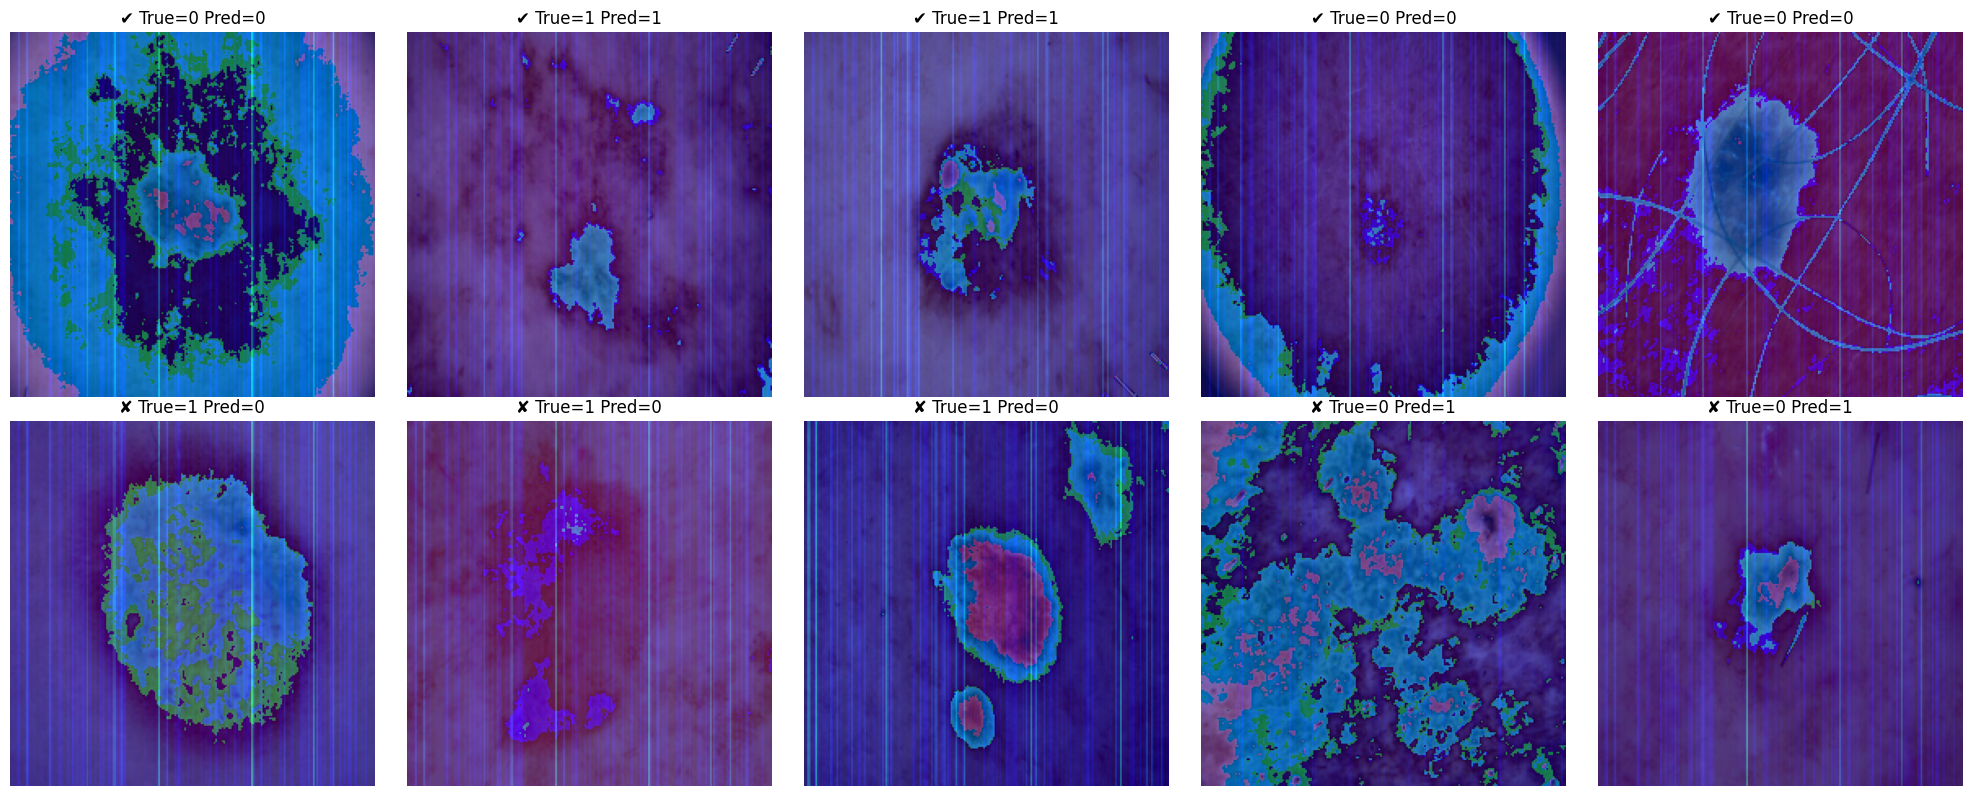

In [11]:


import os
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
from transformers import ViTModel
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from safetensors.torch import load_file
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")
label_map = {"benign": 0, "malignant": 1}
for df in (train_df, val_df, test_df):
    df["binary_class"] = df["binary_class"].map(label_map)

meta_encoder = ColumnTransformer([
    ("age",    StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site",   OneHotEncoder(sparse=False), ["localization"]),
    ("dx",     OneHotEncoder(sparse=False), ["dx_type"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age", "sex", "localization", "dx_type"]])
dummy = pd.DataFrame([{"age": 0, "sex": "male", "localization": "trunk", "dx_type": "histo"}])
metadata_dim = meta_encoder.transform(dummy).shape[1]

class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained(
            "/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/",
            local_files_only=True
        )
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )
    def forward(self, pixel_values, metadata, **kwargs):
        feat = self.vit(pixel_values=pixel_values).pooler_output
        logits = self.classifier(torch.cat((feat, metadata), dim=1))
        return {"logits": logits}

model = ViTWithMeta(metadata_dim=metadata_dim)
state_dict = load_file("./vit-meta-final/checkpoint-251/model.safetensors", device="cpu")
model.load_state_dict(state_dict, strict=False)
model.eval()

class ViTWrapper(nn.Module):
    def __init__(self, vit):
        super().__init__()
        self.vit = vit
    def forward(self, x):
        return self.vit(pixel_values=x).pooler_output

wrapped_vit = ViTWrapper(model.vit)
target_layer = wrapped_vit.vit.encoder.layer[-1].output
cam_extractor = SmoothGradCAMpp(wrapped_vit, target_layer=target_layer)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

correct, incorrect = [], []
for _, row in test_df.iterrows():
    fname = row.image_id
    if not fname.lower().endswith((".jpg", ".png")): fname += ".jpg"
    img_path = os.path.join("/kaggle/working/all_images", fname)
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0)

    meta_row = pd.DataFrame([row[["age", "sex", "localization", "dx_type"]].to_dict()])
    m = torch.tensor(meta_encoder.transform(meta_row), dtype=torch.float)

    out = model(pixel_values=x, metadata=m)
    pred = int(out["logits"].argmax(-1))

    entry = (img, x, pred, int(row.binary_class))
    if pred == row.binary_class:
        if len(correct) < 5: correct.append(entry)
    else:
        if len(incorrect) < 5: incorrect.append(entry)
    if len(correct) == 5 and len(incorrect) == 5:
        break

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col, (img, x, pred, true) in enumerate(correct):
    xg = x.detach().clone().requires_grad_(True)
    _  = wrapped_vit(xg)
    cam = cam_extractor(class_idx=[pred])[0].cpu()
    heat = overlay_mask(
        to_pil_image(transform(img)),
        to_pil_image(cam, mode='F'),
        alpha=0.5
    )
    axes[0, col].imshow(heat)
    axes[0, col].set_title(f"✔ True={true} Pred={pred}")
    axes[0, col].axis("off")

for col, (img, x, pred, true) in enumerate(incorrect):
    xg = x.detach().clone().requires_grad_(True)
    _  = wrapped_vit(xg)
    cam = cam_extractor(class_idx=[pred])[0].cpu()
    heat = overlay_mask(
        to_pil_image(transform(img)),
        to_pil_image(cam, mode='F'),
        alpha=0.5
    )
    axes[1, col].imshow(heat)
    axes[1, col].set_title(f"✘ True={true} Pred={pred}")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Correct", fontsize=16)
axes[1, 0].set_ylabel("Incorrect", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:

import os
import torch
import torch.nn as nn
import pandas as pd
import shap
import matplotlib.pyplot as plt
from transformers import ViTModel
from safetensors.torch import load_file
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1️⃣ Load datasets
train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")

# Label mapping
label_map = {"benign": 0, "malignant": 1}
for df in (train_df, val_df, test_df):
    df["binary_class"] = df["binary_class"].map(label_map)

# 2️⃣ Metadata encoder
meta_encoder = ColumnTransformer([
    ("age",    StandardScaler(),            ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site",   OneHotEncoder(sparse=False), ["localization"]),
    ("dx",     OneHotEncoder(sparse=False), ["dx_type"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age","sex","localization","dx_type"]])

# metadata dim
dummy = pd.DataFrame([{"age":0,"sex":"male","localization":"trunk","dx_type":"histo"}])
metadata_dim = meta_encoder.transform(dummy).shape[1]


print("Tina")
# 3️⃣ Model
class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained(
            "/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/",
            local_files_only=True
        )
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )
    def forward(self, pixel_values, metadata, **kwargs):
        feat   = self.vit(pixel_values=pixel_values).pooler_output
        logits = self.classifier(torch.cat((feat, metadata), dim=1))
        return {"logits": logits}

# Instantiate and load weights
model = ViTWithMeta(metadata_dim=metadata_dim)
sd = load_file("./vit-meta-final/checkpoint-2505/model.safetensors", device="cpu")
model.load_state_dict(sd, strict=False)
model.eval()

# 4️⃣ Dummy image (frozen) for metadata-only explanation
dummy_img = torch.zeros(1, 3, 224, 224)
print("Tina2")
# 5️⃣ Pick a batch of metadata samples to explain
sample_rows = test_df.sample(100, random_state=42)
meta_batch = torch.tensor(meta_encoder.transform(
    sample_rows[["age", "sex", "localization", "dx_type"]]
), dtype=torch.float)

# 6️⃣ Define a wrapper around the model to only vary metadata
def model_metadata_only(meta_batch_numpy):
    meta_batch = torch.tensor(meta_batch_numpy, dtype=torch.float)
    batch_size = meta_batch.shape[0]
    imgs = dummy_img.expand(batch_size, -1, -1, -1)  # replicate dummy images
    with torch.no_grad():
        outputs = model(pixel_values=imgs, metadata=meta_batch)
    return outputs["logits"].softmax(-1)[:, 1].cpu().numpy()  # malignant probability

print("Tinacheckoint")

# 7️⃣ SHAP explainer
explainer = shap.Explainer(model_metadata_only, meta_batch.numpy())

# 8️⃣ SHAP values
shap_values = explainer(meta_batch.numpy())

print("Tina1")
# 9️⃣ SHAP plot
shap.summary_plot(
    shap_values,
    features=sample_rows[["age", "sex", "localization", "dx_type"]],
    feature_names=["age", "sex", "localization", "dx_type"],
    show=True
)
print("Tinamain")

In [75]:
!pip install torchcam --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 967.5 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 3.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is inc

In [77]:


import os
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torchvision import transforms
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from transformers import ViTModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

train_df = pd.read_csv("/kaggle/working/data/processed/train_split.csv")
val_df   = pd.read_csv("/kaggle/working/data/processed/val_split.csv")
test_df  = pd.read_csv("/kaggle/working/data/processed/test_split.csv")

label_map = {"benign": 0, "malignant": 1}
for df in (train_df, val_df, test_df):
    df["binary_class"] = df["binary_class"].map(label_map)

meta_encoder = ColumnTransformer([
    ("age",    StandardScaler(), ["age"]),
    ("gender", OneHotEncoder(sparse=False), ["sex"]),
    ("site",   OneHotEncoder(sparse=False), ["localization"]),
    ("dx",     OneHotEncoder(sparse=False), ["dx_type"])
])
meta_encoder.fit(pd.concat([train_df, val_df, test_df])[["age","sex","localization","dx_type"]])

class SkinLesionWithMeta(Dataset):
    def __init__(self, df, img_dir, transform, meta_encoder):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        m = meta_encoder.transform(self.df[['age', 'sex', 'localization', 'dx_type']])
        self.meta = m.toarray() if hasattr(m, "toarray") else m
        self.labels = self.df['binary_class'].astype(int).values

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_path = os.path.join("/kaggle/working/all_images", row.image_id)
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        meta = torch.tensor(self.meta[i], dtype=torch.float)
        label = torch.tensor(self.labels[i], dtype=torch.long)
        return {"pixel_values": img, "metadata": meta, "labels": label}

class ViTWithMeta(nn.Module):
    def __init__(self, metadata_dim, num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained("/kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/", local_files_only=True)
        hidden = self.vit.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + metadata_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, pixel_values, metadata, **kwargs):
        feat = self.vit(pixel_values=pixel_values).pooler_output
        logits = self.classifier(torch.cat((feat, metadata), dim=1))
        return {"logits": logits}

class TrainerWithMeta(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        pixel_values = inputs.pop("pixel_values")
        metadata = inputs.pop("metadata")
        outputs = model(pixel_values, metadata)
        logits = outputs["logits"]
        weights = torch.tensor([1.0, 3.0]).to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labels = p.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = SkinLesionWithMeta(train_df, "/kaggle/working/all_images", transform, meta_encoder)
val_ds   = SkinLesionWithMeta(val_df, "/kaggle/working/all_images", transform, meta_encoder)
test_ds  = SkinLesionWithMeta(test_df, "/kaggle/working/all_images", transform, meta_encoder)

metadata_dim = meta_encoder.transform(pd.DataFrame([{
    "age":0, "sex":"male", "localization":"trunk", "dx_type":"histo"
}])).shape[1]

model = ViTWithMeta(metadata_dim=metadata_dim)

args = TrainingArguments(
    output_dir="./vit-meta-4features-final",
    do_train=True,
    do_eval=True,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    logging_steps=50,
    save_steps=300,
    save_total_limit=2,
    remove_unused_columns=False,
    label_names=["labels"],
    report_to="none"
)

trainer = TrainerWithMeta(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

os.makedirs("./vit-meta-4features-final/final", exist_ok=True)
torch.save(model.state_dict(), "./vit-meta-4features-final/final/pytorch_model.bin")

test_preds = trainer.predict(test_ds)
test_true = test_preds.label_ids
test_pred = test_preds.predictions.argmax(-1)

print("\n Final Test Set Performance:")
print("Test Accuracy:", accuracy_score(test_true, test_pred))
print("\n Test Classification Report:\n", classification_report(test_true, test_pred, target_names=["Benign", "Malignant"]))


`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/saved-models/saved_models/vit_final_model/checkpoint-2400/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,0.386600
100,0.216900
150,0.237500
200,0.213500
250,0.163200
300,0.139400
350,0.188600
400,0.155900
450,0.174600
500,0.167100



📊 Final Test Set Performance:
Test Accuracy: 0.9261477045908184

📊 Test Classification Report:
               precision    recall  f1-score   support

      Benign       0.94      0.97      0.95       806
   Malignant       0.86      0.74      0.80       196

    accuracy                           0.93      1002
   macro avg       0.90      0.86      0.88      1002
weighted avg       0.92      0.93      0.92      1002

